# Fourth Question
My fourth question I wanted to answer builds up from question 3, which categorys are most common. I found that the output wasnt very insightfull, the most common category is Abfall/Sammelstelle but there is no information how they compare to the rest of the categorys. I got the idea that I could write a function that when given the name of the neighbourhood, would create a piechart of the categorys. So my fourth question is: "How does the numbers of reports vary per category in a neighbourhood?".

## Workflow/Plan
1. Reuse code from question 3
2. Create piechart on one neighbourhood
3. make piechart creation as a function

## 1. Reuse code

In [1]:
# Code from question 3

# Load Librarys
import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib.pyplot as plt

# Load data
data_gpkg = gpd.read_file("../data/raw/ZuriWieNeu_gpkg_data/data.gpkg").to_crs(epsg=2056)
boundaries_gpkg_v = gpd.read_file("../data/raw/boundaries_GPKG/data.gpkg",
 layer="stzh.adm_statistische_quartiere_v").to_crs(epsg=2056) # Layer for mapping

# Filter data
data_subset = data_gpkg[["geometry", "service_code"]]
boundaries_subset = boundaries_gpkg_v[["geometry", "qname"]]

# Spatial Join: distribute points to neighbourhoods
joined = gpd.sjoin(data_subset, boundaries_subset, how= "left", predicate="within")

# Count Numbers of reports per neighbourhood per category
counts = (
    joined
    .groupby(["qname", "service_code"])
    .size()
    .reset_index(name="n_reports")
)

## 2. Create piechart of Affoltern

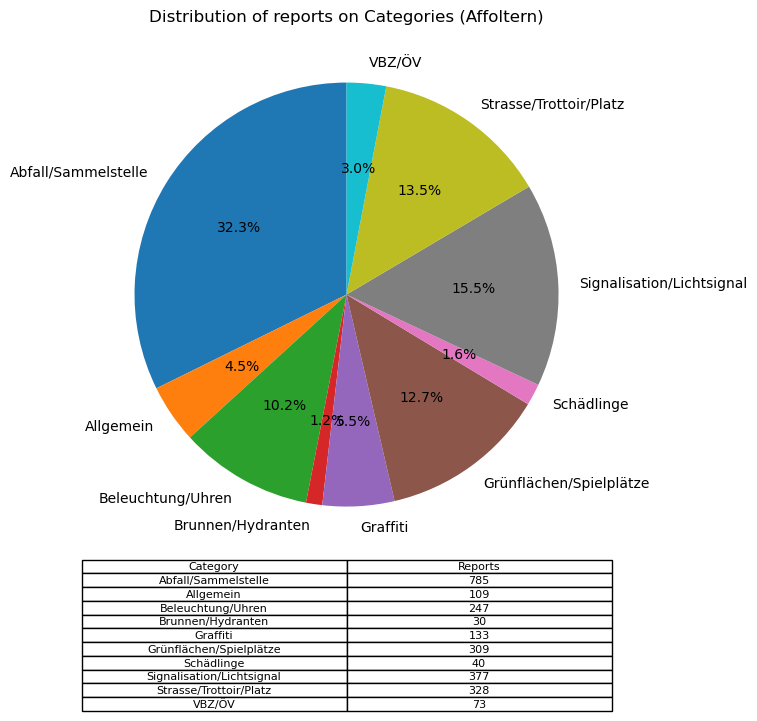

In [30]:
# Filter for Affoltern
affoltern = counts[counts["qname"] == "Affoltern"]

# create figure and ax
fig, ax = plt.subplots(figsize=(8, 10))

# Pie chart
ax.pie(
    affoltern["n_reports"],
    labels=affoltern["service_code"],
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title("Distribution of reports on Categories (Affoltern)")


# prepare table
table_data = affoltern[["service_code", "n_reports"]].values

# add table
table = plt.table(
    cellText=table_data,
    colLabels=["Category", "Reports"],
    loc='bottom',
    cellLoc='center'
)

# set textsize in table
table.auto_set_font_size(False)
table.set_fontsize(8)


# Tabelle etwas strecken für bessere Lesbarkeit
table.scale(1, 1.2)


# Mehr Platz unten schaffen für die Tabelle
plt.subplots_adjust(bottom=0.35)

plt.show()


## 3. make function

In [19]:
def category_pie_for_qname(df, qname):
    
    """
    Create a pie chart with an accompanying table showing the distribution
    of report categories for a specific neighbourhood (qname).

    Parameters
    ----------
    df : pandas.DataFrame
        Input DataFrame containing at least the following columns:
        - 'qname' : Name of the neighbourhood
        - 'service_code' : Category of the report
        - 'n_reports' : Number of reports per category

    qname : str
        Name of the neighbourhood to filter and visualize.

    Returns
    -------
    The function does not return any value. It displays the plot directly.

    Examples
    --------
    category_pie_for_qname(counts, "Affoltern")
    Displays pie chart and table for the "Affoltern" neighbourhood
    """

    # check if qname is available in df
    if qname not in df["qname"].values:
        print(f"Error: '{qname}' not found in Dataframe")
        return
    
    # filter data
    subset = df[df["qname"] == qname]
    
    # Create figure
    fig, ax = plt.subplots(figsize=(8, 10))
    
    # Pie chart
    ax.pie(
        subset["n_reports"],
        labels=subset["service_code"],
        autopct='%1.1f%%',
        startangle=90
    )
    
    ax.set_title(f"Distribution of reports on Categories ({qname})")
    ax.axis('equal')
    
    # prepare table
    table_data = subset[["service_code", "n_reports"]].values
    
    # add table
    table = plt.table(
        cellText=table_data,
        colLabels=["Category", "Reports"],
        loc='bottom',
        cellLoc='center'
    )
    
    # set textsize in table
    table.auto_set_font_size(False)
    table.set_fontsize(8)
    
    # strech table
    table.scale(1, 1.2)
    
    # more space
    plt.subplots_adjust(bottom=0.35)
    
    plt.show()

### Tryout function

In [ ]:
# print names of neighbourhood in dataframe
print(counts["qname"].unique())

<ArrowStringArray>
[           'Affoltern',          'Albisrieden',         'Alt-Wiedikon',
           'Altstetten',                 'City',                 'Enge',
          'Escher Wyss',             'Fluntern',          'Friesenberg',
        'Gewerbeschule',                 'Hard',           'Hirslanden',
           'Hirzenbach',          'Hochschulen',            'Hottingen',
                'Höngg',          'Langstrasse',             'Leimbach',
            'Lindenhof',            'Mühlebach',           'Oberstrass',
             'Oerlikon',              'Rathaus',              'Saatlen',
 'Schwamendingen-Mitte',              'Seebach',              'Seefeld',
             'Sihlfeld',          'Unterstrass',              'Weinegg',
                 'Werd',            'Wipkingen',              'Witikon',
          'Wollishofen']
Length: 34, dtype: str


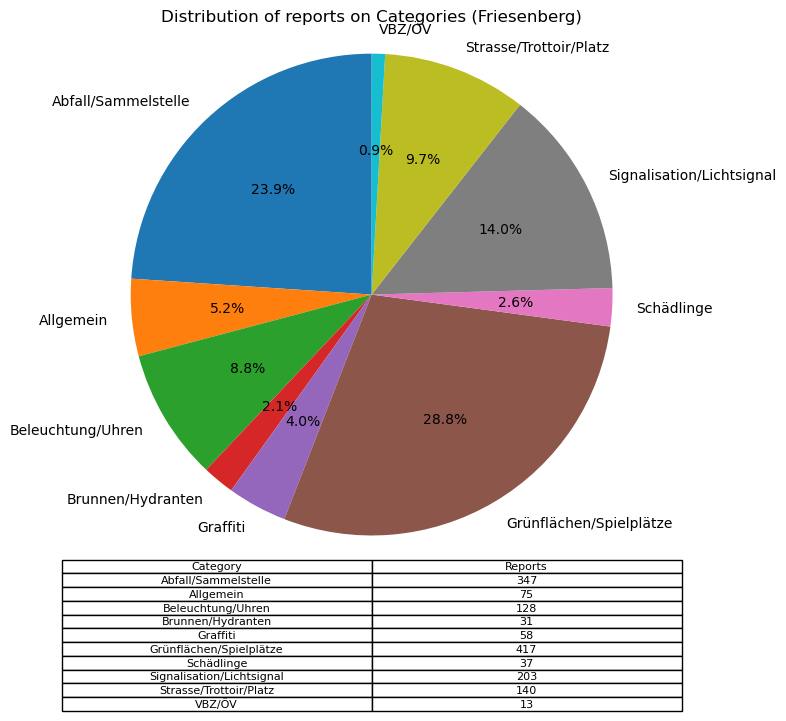

None

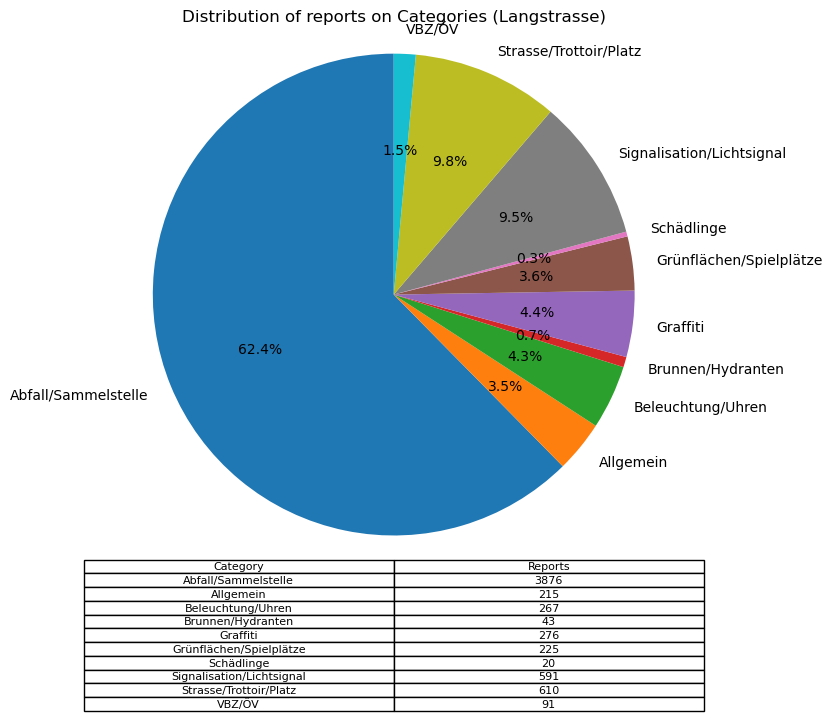

None

In [29]:
display(category_pie_for_qname(counts,"Friesenberg"))
display(category_pie_for_qname(counts,"Langstrasse"))
